CS 179 PROJECT!!!!

In [61]:
import sys
!{sys.executable} -m pip install yfinance
!{sys.executable} -m pip install hmmlearn

import yfinance as yf
import numpy as np
import pandas as pd
from hmmlearn import hmm
import matplotlib.pyplot as plt

ACTIVATE THE DATA

In [62]:
# load in data and calculate log returns
data = yf.download("SPY", start="2015-01-01", end="2024-12-31")
close_column = data["Close"].squeeze()
log_returns = {}

for index, (date, price) in enumerate(close_column.items()):
    if (index != 0):
        yesterday = close_column.shift(1)[date]
        log = np.log(price / yesterday)
        print(f"Log of date {date}: {log}")
        log_returns[date] = log
log_returns = pd.Series(log_returns)

[*********************100%***********************]  1 of 1 completed

Log of date 2015-01-05 00:00:00: -0.018225018145410346
Log of date 2015-01-06 00:00:00: -0.009463472685247765
Log of date 2015-01-07 00:00:00: 0.012384405908326615
Log of date 2015-01-08 00:00:00: 0.01758941522536229
Log of date 2015-01-09 00:00:00: -0.008045831530400397
Log of date 2015-01-12 00:00:00: -0.007864845091603683
Log of date 2015-01-13 00:00:00: -0.002816363637885157
Log of date 2015-01-14 00:00:00: -0.006055866435652933
Log of date 2015-01-15 00:00:00: -0.009202420555654197
Log of date 2015-01-16 00:00:00: 0.013029042781290445
Log of date 2015-01-20 00:00:00: 0.00213021945785084
Log of date 2015-01-21 00:00:00: 0.005035170208501654
Log of date 2015-01-22 00:00:00: 0.014761624644866517
Log of date 2015-01-23 00:00:00: -0.005497812102078158
Log of date 2015-01-26 00:00:00: 0.002338793587234155
Log of date 2015-01-27 00:00:00: -0.01327805960870513
Log of date 2015-01-28 00:00:00: -0.012907439046309505
Log of date 2015-01-29 00:00:00: 0.009201423318550856
Log of date 2015-01-3

SET TEST/TRAINING SPLITS

In [63]:
# 1 test set from Jan 2024 - Dec 2024
test_set = log_returns["2024-01-01":"2024-12-31"]

# 5 training sets of varying length
train_sets = [
    log_returns["2023-01-01":"2023-12-31"],
    log_returns["2022-01-01":"2023-12-31"],
    log_returns["2021-01-01":"2023-12-31"],
    log_returns["2020-01-01":"2023-12-31"],
    log_returns["2019-01-01":"2023-12-31"]
]

PLOT DATA

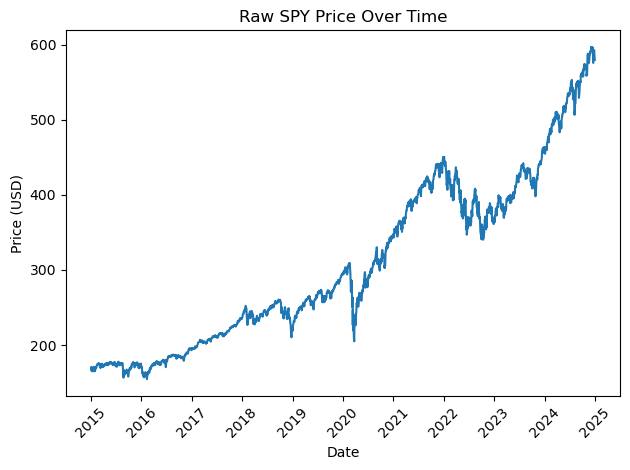

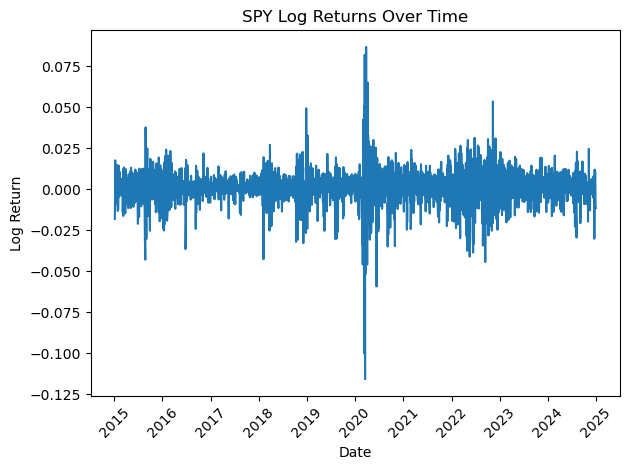

In [64]:
# raw SPY price over time
plt.plot(close_column)
plt.title("Raw SPY Price Over Time")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# log returns
plt.plot(log_returns)
plt.title("SPY Log Returns Over Time")
plt.xlabel("Date")
plt.ylabel("Log Return")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

DATA SHAPE AND MODEL SETUP

In [68]:
data_shape = log_returns.values.reshape(-1, 1)
hmm_model = hmm.GaussianHMM(n_components=3, covariance_type="full", n_iter=10000)

FIT ON TRAINING SET

In [69]:
train_set_reshape = train_sets[4].values.reshape(-1, 1)
trained_model = hmm_model.fit(train_set_reshape)

SCORE AND VISUALIZE TEST SET

In [72]:
test_set_reshape = test_set.values.reshape(-1, 1)
test_set_score = trained_model.score(test_set_reshape)
print(test_set_score)

846.0141082622849


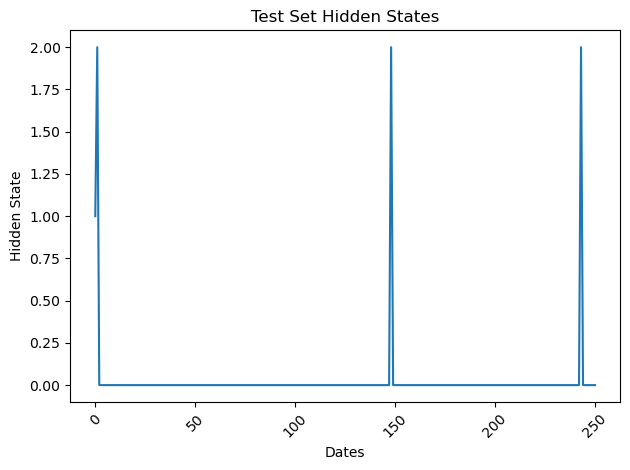

In [75]:
test_set_hidden = trained_model.predict(test_set_reshape)
plt.plot(test_set_hidden)
plt.title("Test Set Hidden States")
plt.xlabel("Dates")
plt.ylabel("Hidden State")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()